[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLO26 Object Detection on a Custom Dataset

---

[![roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/how-to-train-yolo26-custom-data/) [![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

YOLO26 introduces a unified architecture designed to support detection, segmentation, and pose tasks within a single model family. The model uses an anchor-free design with a decoupled head.

## Setup

### Configure API keys

To fine-tune YOLO26, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Runtime` -> `Change runtime type` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Mon Mar  9 04:09:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


### Install dependencies required for YOLO26

In [3]:
%pip install -q "ultralytics>=8.4.0" supervision roboflow

# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.7/112.6 GB disk)


### Download example data

Downloads example images for testing. You can use these or replace them with your own images.

In [4]:
!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg

## Inference with model pre-trained on COCO dataset

### CLI

**NOTE:** CLI requires no customization or Python code. You can simply run all tasks from the terminal with the yolo command.

In [5]:
!yolo task=detect mode=predict model=yolo26m.pt source={HOME}/dog-2.jpeg save=True verbose=False

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,411,132 parameters, 0 gradients, 68.2 GFLOPs
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


**NOTE:** Result annotated image got saved in `{HOME}/runs/detect/predict/`. Let's display it.

In [6]:
!ls -la {HOME}/runs/detect/predict/

total 420
drwxr-xr-x 2 root root   4096 Mar  9 04:11 .
drwxr-xr-x 3 root root   4096 Mar  9 04:11 ..
-rw-r--r-- 1 root root 420529 Mar  9 04:11 dog-2.jpg


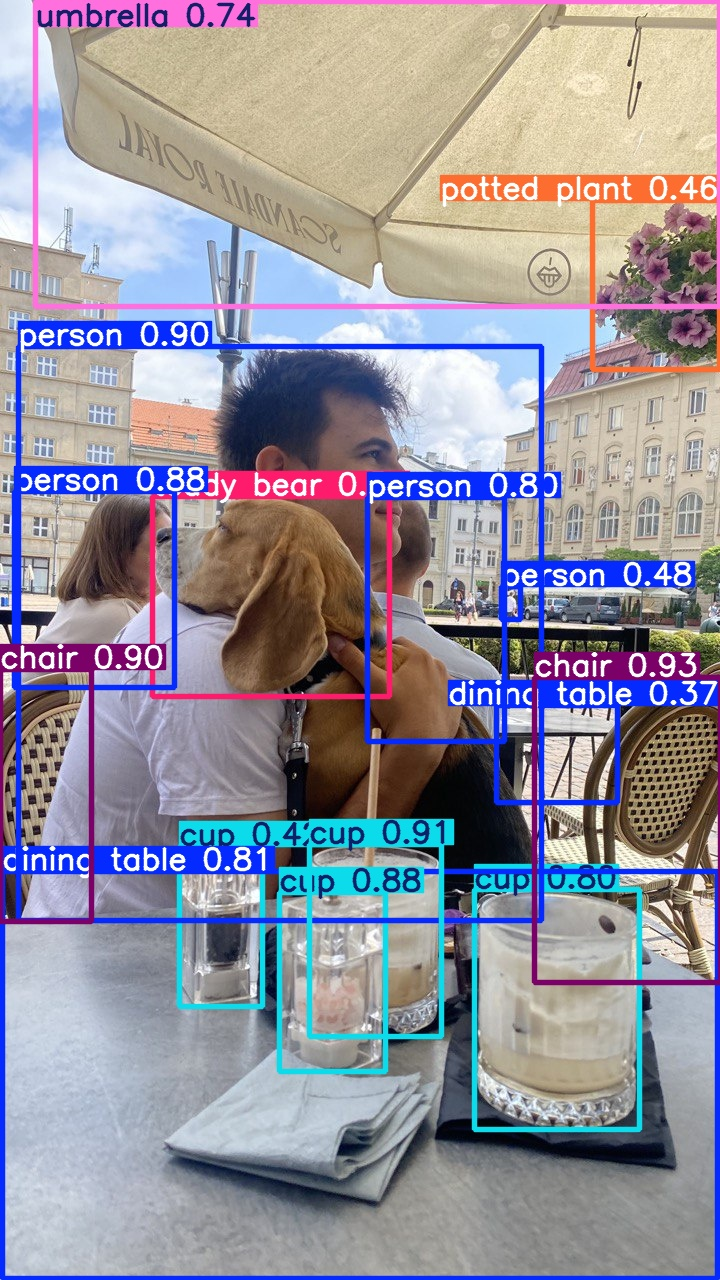

In [7]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/predict/dog-2.jpg', width=600)

### SDK

In [8]:
from ultralytics import YOLO
from PIL import Image

# Load a pre-trained YOLOv8n model
model = YOLO('yolov8n.pt')
image = Image.open(f'{HOME}/dog-2.jpeg')
result = model.predict(image, verbose=False)[0]

**NOTE:** The obtained `result` object stores information about the location, classes, and confidence levels of the detected objects.

In [9]:
result.boxes.xyxy

tensor([[2.0884e+01, 3.3477e+02, 5.4287e+02, 9.1678e+02],
        [1.8776e+00, 6.7109e+02, 9.1082e+01, 9.2184e+02],
        [5.5034e+02, 6.7337e+02, 7.2000e+02, 9.7610e+02],
        [3.2947e-01, 8.9850e+02, 7.1631e+02, 1.2786e+03],
        [1.3609e+01, 4.9344e+02, 1.7855e+02, 6.9860e+02],
        [2.8061e+02, 8.7584e+02, 3.8423e+02, 1.0721e+03],
        [1.7764e+02, 8.4351e+02, 2.6279e+02, 1.0036e+03],
        [4.7429e+02, 8.8982e+02, 6.4429e+02, 1.1317e+03],
        [3.1920e+01, 1.1233e+00, 7.1836e+02, 3.0772e+02],
        [3.1262e+02, 8.4298e+02, 4.4226e+02, 1.0412e+03],
        [4.9180e+00, 4.9618e+02, 1.7931e+02, 9.1072e+02]], device='cuda:0')

In [10]:
result.boxes.conf

tensor([0.9149, 0.7878, 0.7482, 0.7426, 0.7104, 0.5931, 0.5891, 0.4969, 0.4954, 0.4105, 0.3309], device='cuda:0')

In [11]:
result.boxes.cls

tensor([ 0., 56., 56., 60.,  0., 41., 41., 41., 25., 41.,  0.], device='cuda:0')

**NOTE:** YOLO26 can be easily integrated with `supervision` using the familiar `from_ultralytics` connector.

In [12]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

In [13]:
import supervision as sv
from PIL import Image

def annotate(image: Image.Image, detections: sv.Detections) -> Image.Image:
    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)

    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator(
        text_color=sv.Color.BLACK,
        text_scale=text_scale,
        smart_position=True
    )

    out = image.copy()
    out = box_annotator.annotate(out, detections)
    out = label_annotator.annotate(out, detections)
    out.thumbnail((1000, 1000))
    return out

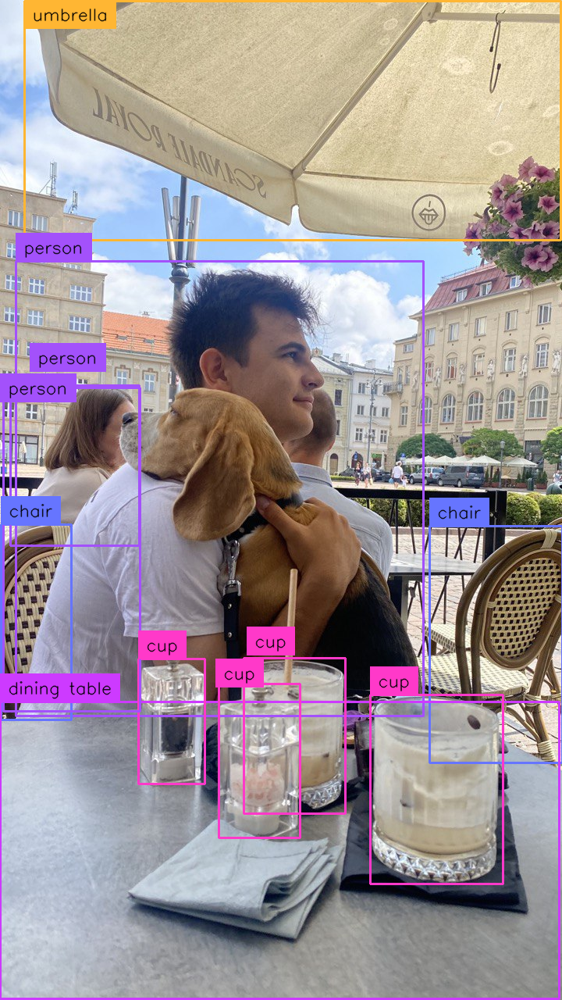

In [14]:
annotated_image = annotate(image, detections)
annotated_image

## Fine-tune YOLO26 on custom dataset

**NOTE:** When training YOLO26, make sure your data is located in `datasets`. If you'd like to change the default location of the data you want to use for fine-tuning, you can do so through Ultralytics' `settings.json`. In this tutorial, we will use one of the [datasets](https://universe.roboflow.com/liangdianzhong/-qvdww) available on [Roboflow Universe](https://universe.roboflow.com/). When downloading, make sure to select the `yolov11` export format.

In [15]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("roboflow-jvuqo")
project = rf.workspace("dora-nkhz4").project("m4t3_tarea_dora_vaca")
version = project.version(3)
dataset = version.download("yolo26")

/content/datasets
loading Roboflow workspace...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to M4T3_TAREA_DORA_VACA-3 in yolo26:: 100%|██████████| 291/291 [00:00<00:00, 500.20it/s]


## Custom Training

In [16]:
%cd {HOME}

!yolo task=detect mode=train model=yolo26m.pt data={dataset.location}/data.yaml epochs=30 imgsz=640 plots=True

/content
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/M4T3_TAREA_DORA_VACA-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [17]:
!ls {HOME}/runs/detect/train/

args.yaml			 labels.jpg	     train_batch1.jpg
BoxF1_curve.png			 results.csv	     train_batch2.jpg
BoxP_curve.png			 results.png	     val_batch0_labels.jpg
BoxPR_curve.png			 train_batch0.jpg    val_batch0_pred.jpg
BoxR_curve.png			 train_batch140.jpg  weights
confusion_matrix_normalized.png  train_batch141.jpg
confusion_matrix.png		 train_batch142.jpg


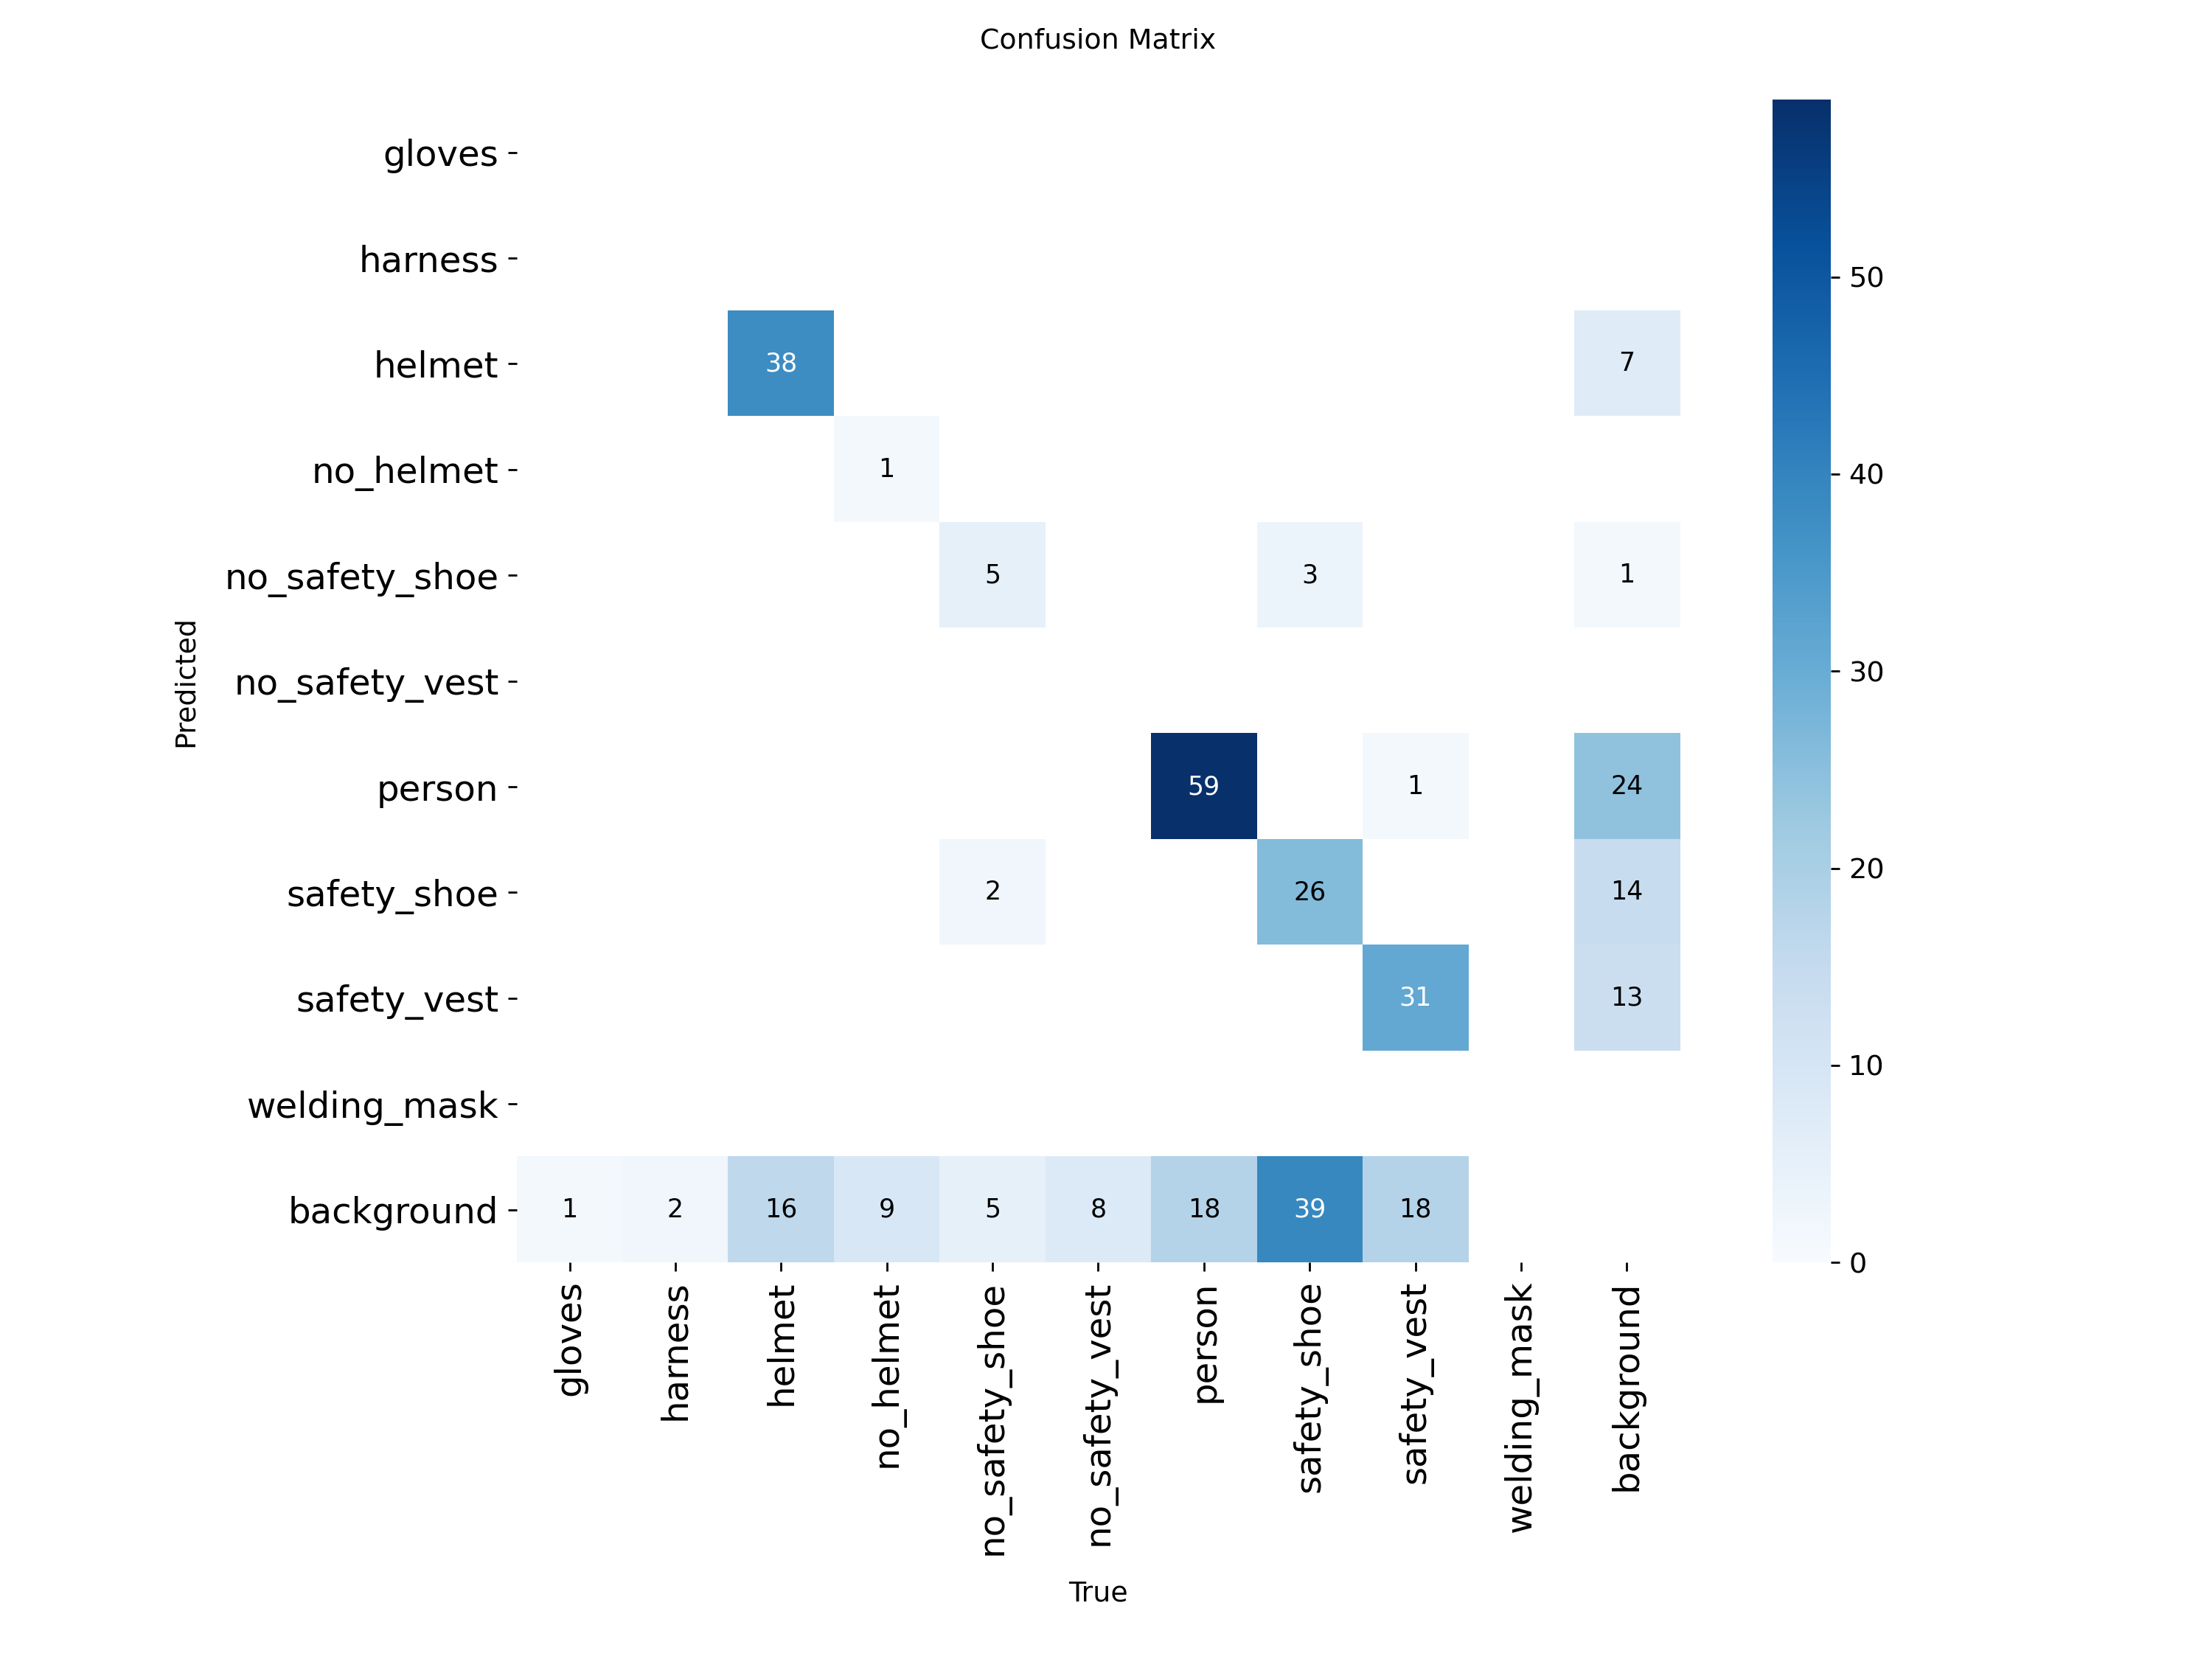

In [18]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

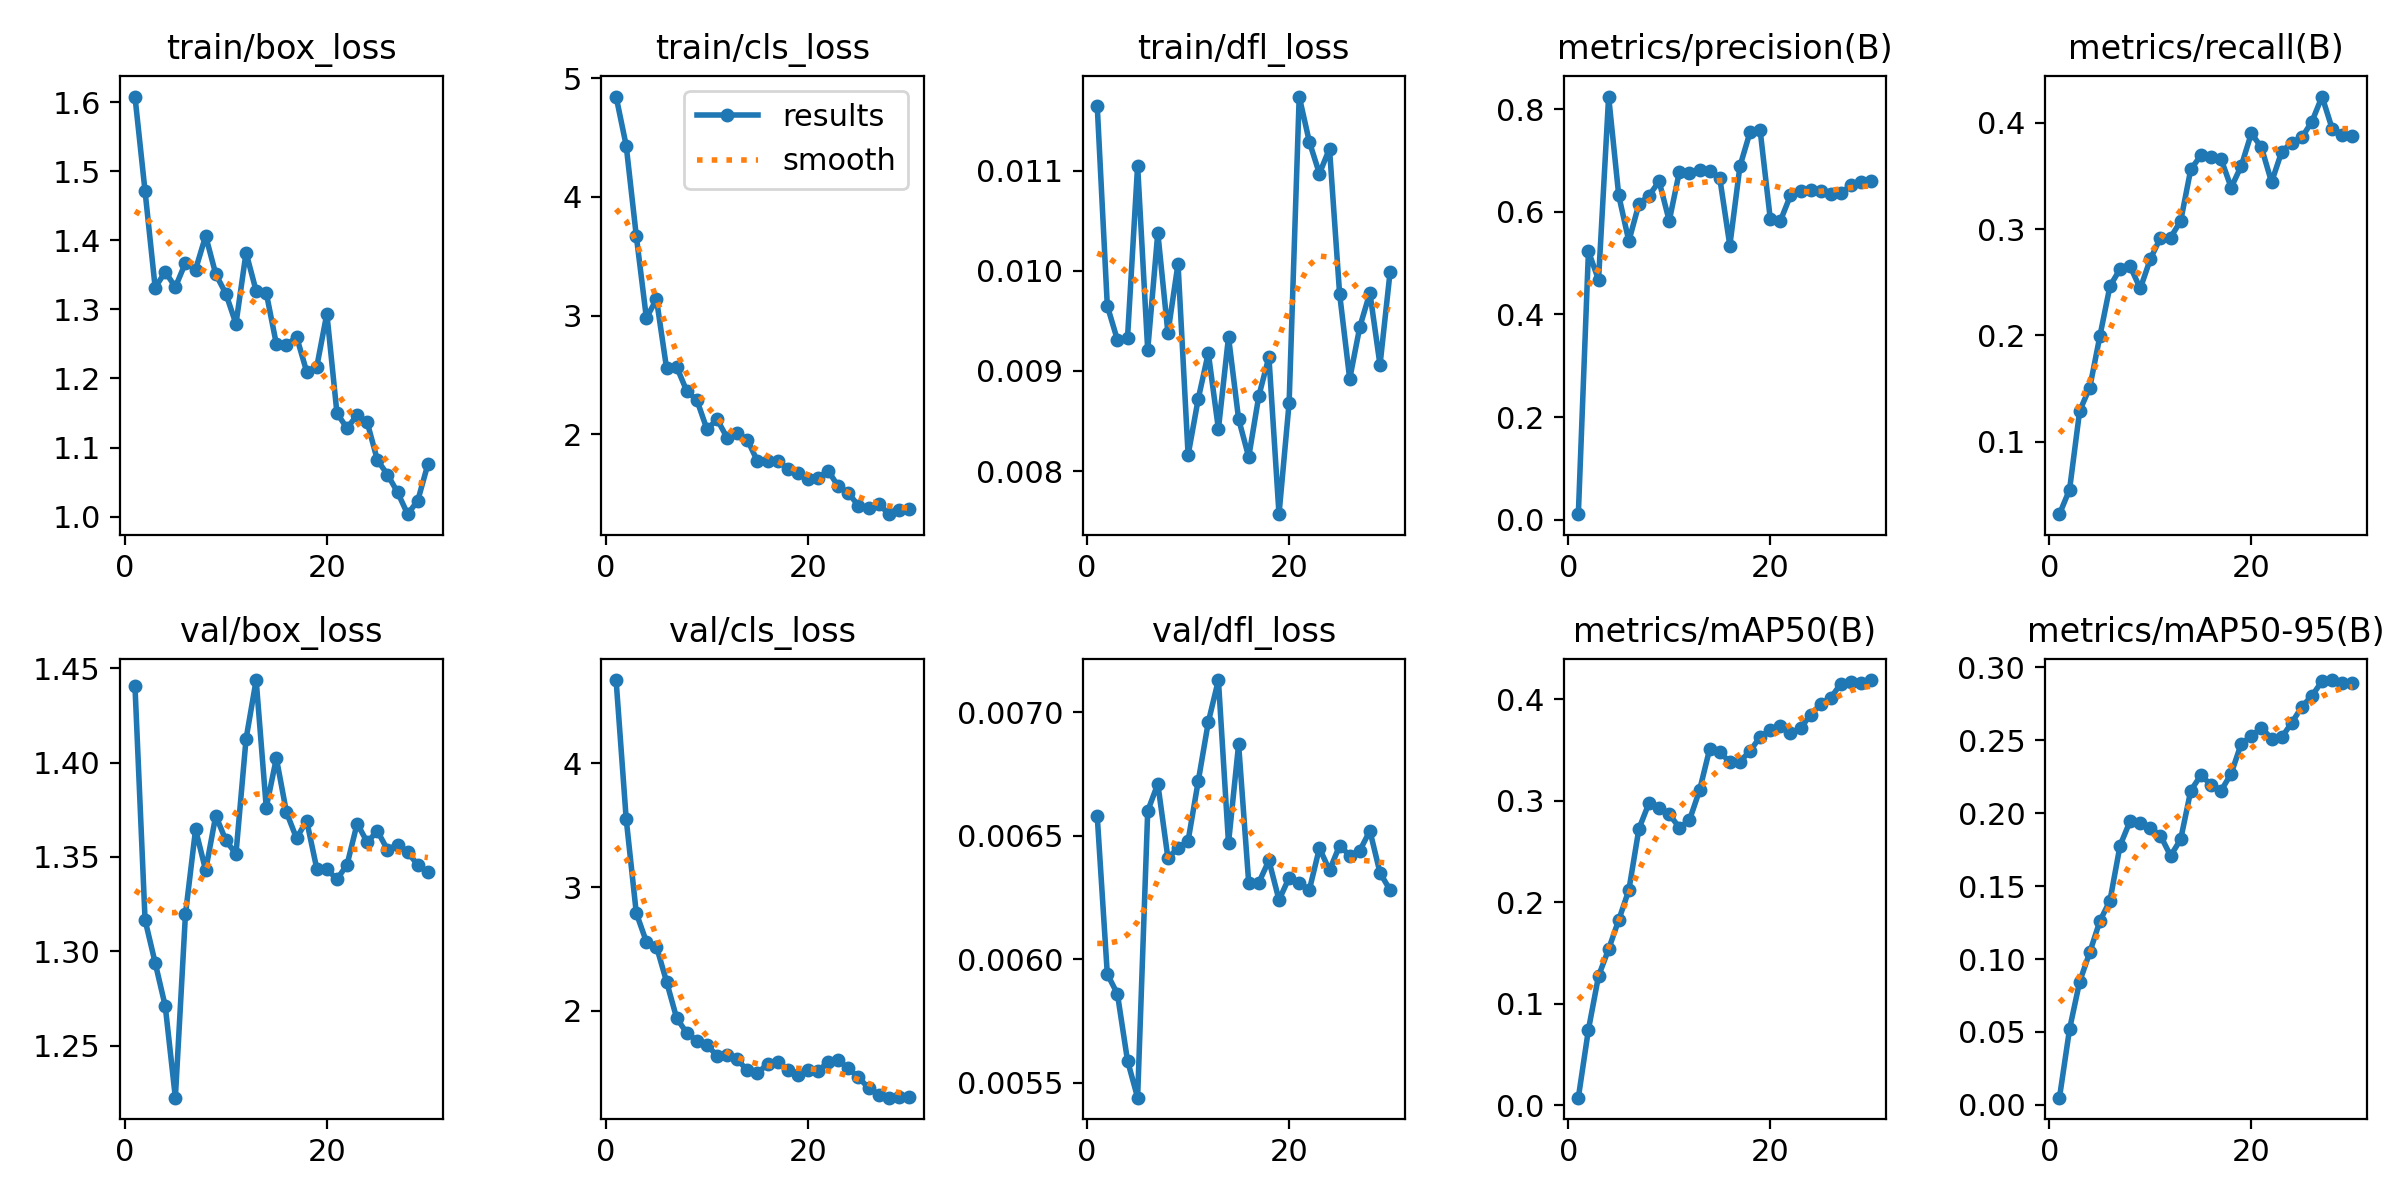

In [19]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

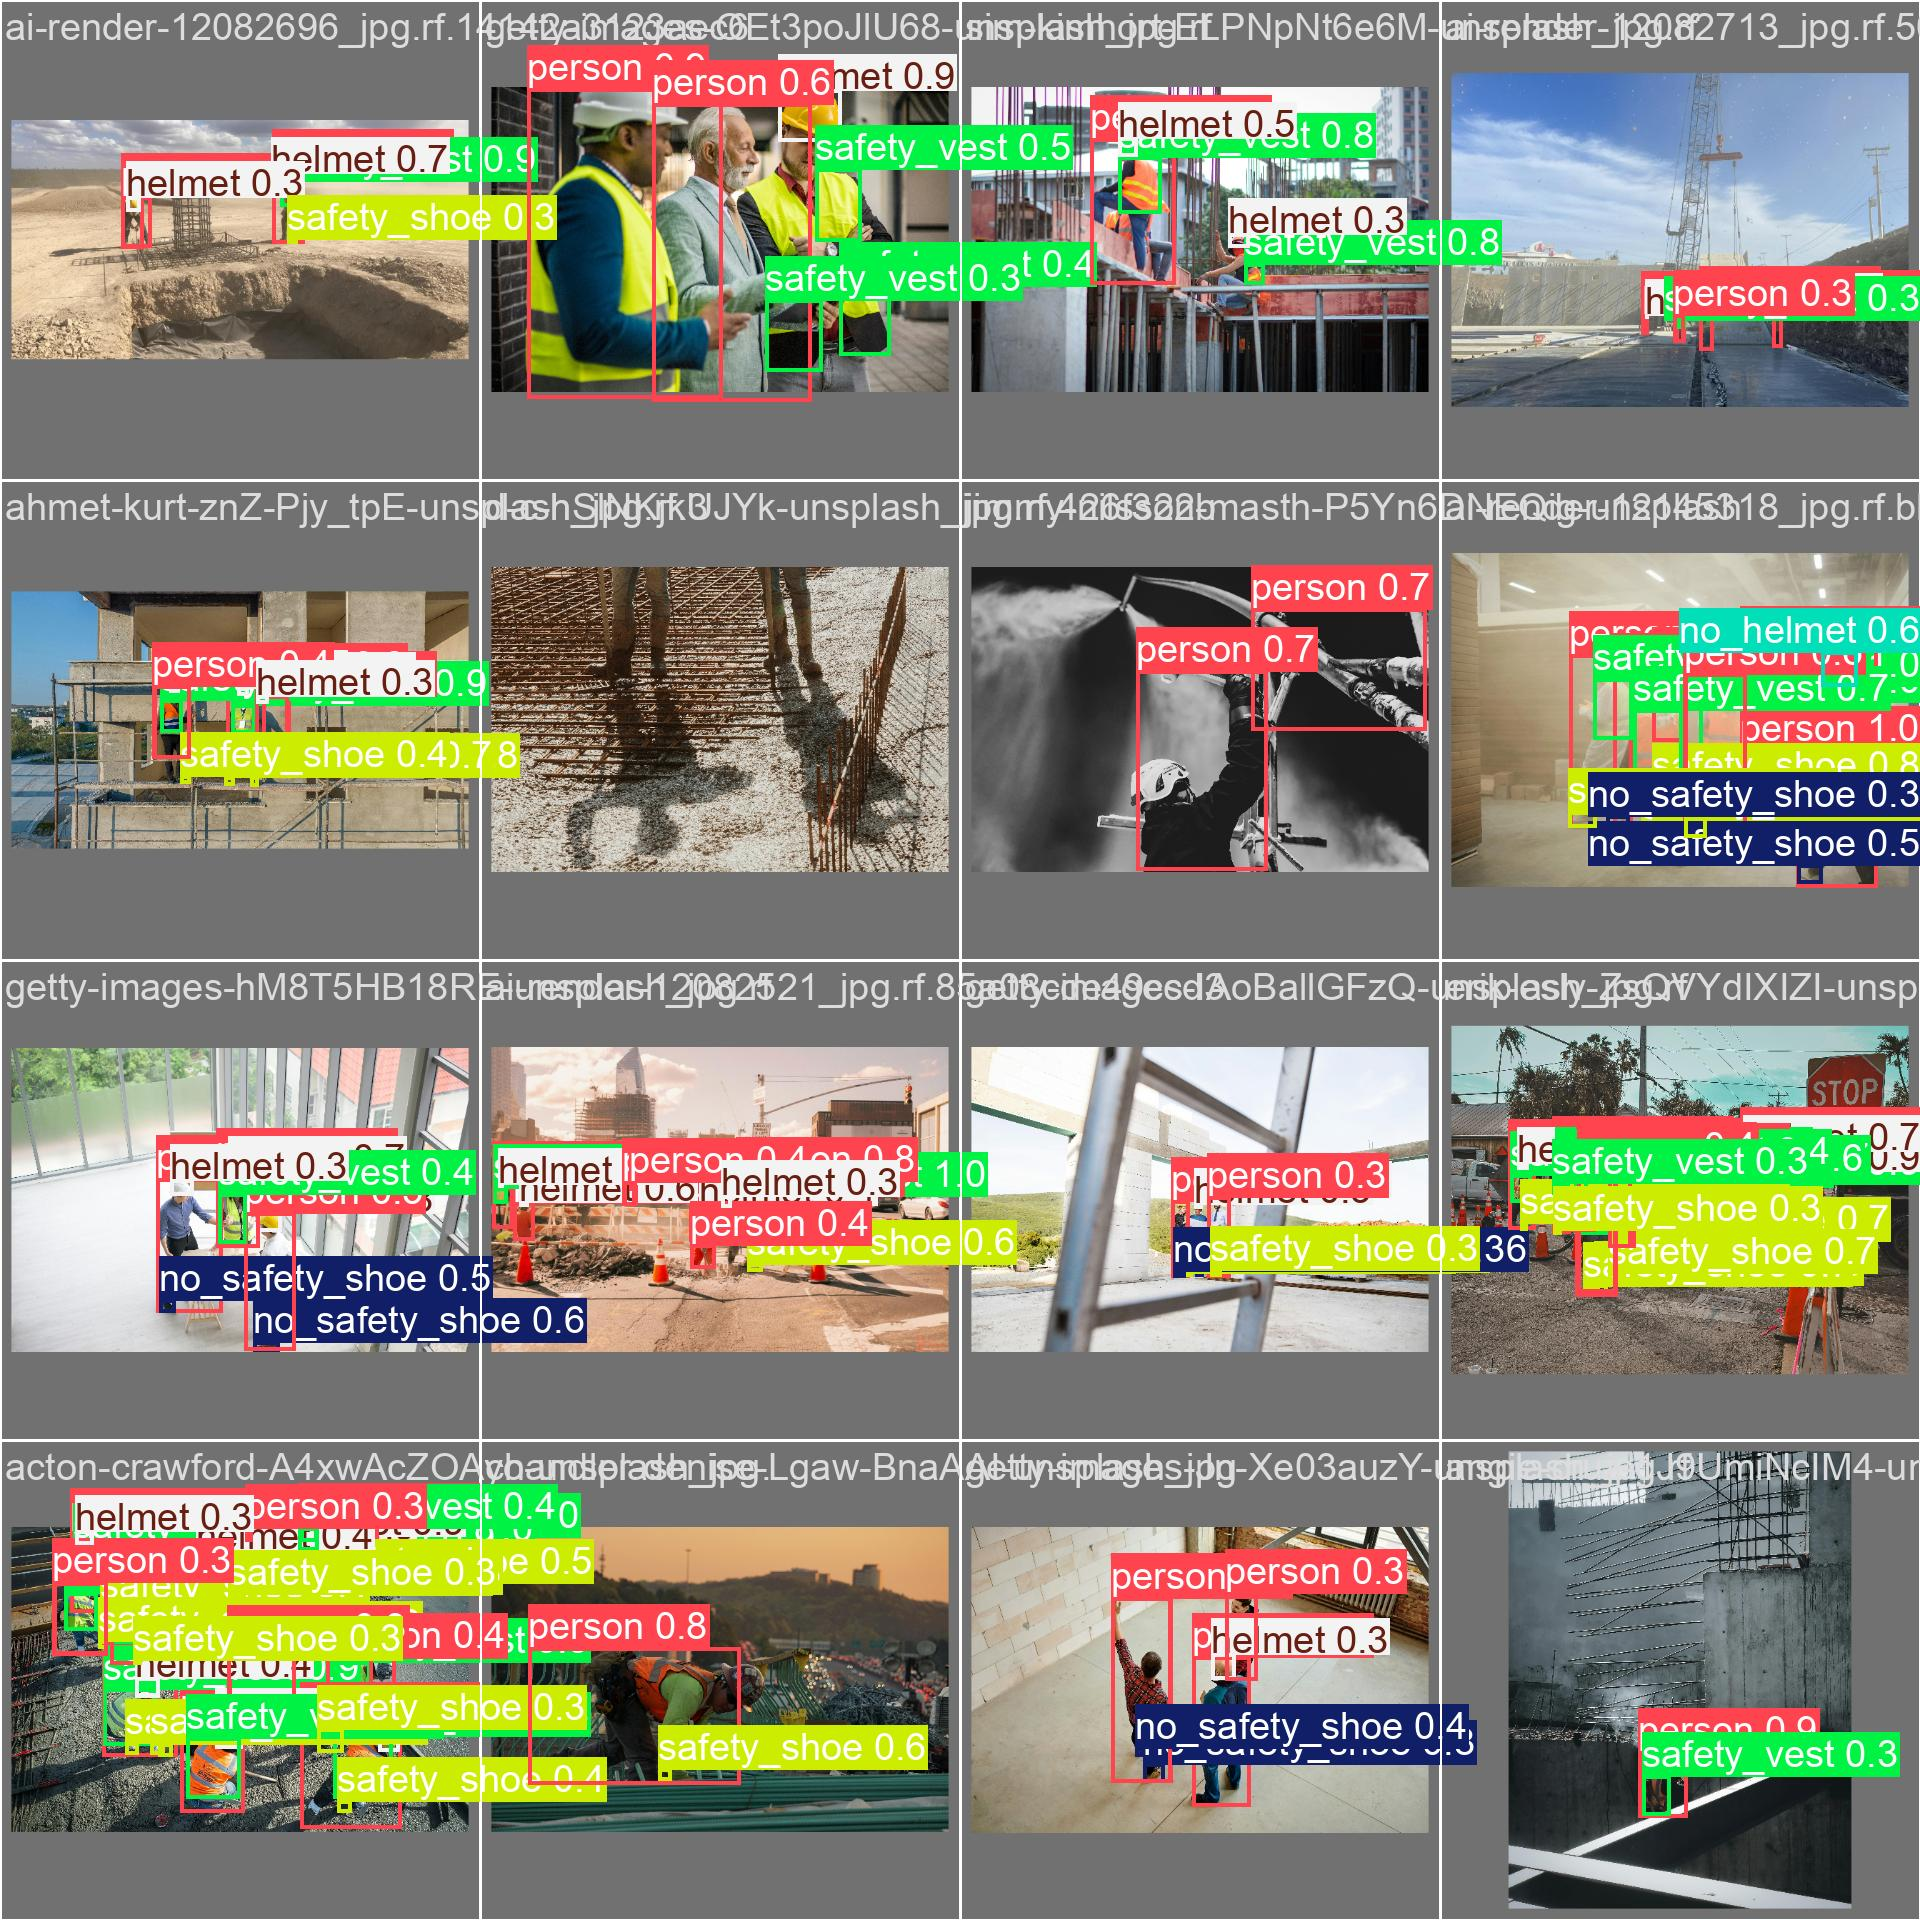

In [20]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [21]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,357,162 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3535.9±1363.1 MB/s, size: 1371.0 KB)
val: Scanning /content/datasets/M4T3_TAREA_DORA_VACA-3/valid/labels.cache... 22 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 22/22 3.4Mit/s 0.0s
val: /content/datasets/M4T3_TAREA_DORA_VACA-3/valid/images/ahmet-kurt-znZ-Pjy_tpE-unsplash_jpg.rf.3980495454a7fedc8535bd5db898a5a1.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.5s/it 2.9s
                   all         22        282      0.654      0.395      0.417       0.29
                gloves          1          1          0          0    0.00248    0.00149
               harness          2          2          1          0     0.0148    0.00724
                helmet         18     